# YOLO26 Training on NUDT-SIRST
Built specifically for the exact Kaggle NUDT-SIRST directory structure with `Sample_1\frame_XXXX.png` format in the CSVs.

In [ ]:
!pip install ultralytics pandas -q

In [ ]:
import os
import pandas as pd
import yaml
import shutil
from ultralytics import YOLO

In [ ]:
DATASET_ROOT = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'annotation_train.csv' in files:
        DATASET_ROOT = root
        break
4
if not DATASET_ROOT:56665
    raise FileNotFoundError("Could not find annotation_train.csv in /kaggle/input!")

print(f"Found Dataset Root: {DATASET_ROOT}")

IMAGES_ROOT = os.path.join(DATASET_ROOT, 'nudtsirst')
print(f"Target Images Directory: {IMAGES_ROOT}")4

WORKING_DIR = '/kaggle/working/yolo26_dataset'
os.makedirs(os.path.join(WORKING_DIR, 'images/train'), exist_ok=True)
os.makedirs(os.path.join(WORKING_DIR, 'images/val'), exist_ok=True)
os.makedirs(os.path.join(WORKING_DIR, 'labels/train'), exist_ok=True)
os.makedirs(os.path.join(WORKING_DIR, 'labels/val'), exist_ok=True)

Found Dataset Root: /kaggle/input/datasets/minhngt02/nudtsirst
Target Images Directory: /kaggle/input/datasets/minhngt02/nudtsirst/nudtsirst


In [ ]:
import os
import pandas as pd
import yaml

WORKING_DIR = '/kaggle/working/yolo26_dataset'
os.makedirs(os.path.join(WORKING_DIR, 'images/train'), exist_ok=True)
os.makedirs(os.path.join(WORKING_DIR, 'images/val'), exist_ok=True)
os.makedirs(os.path.join(WORKING_DIR, 'labels/train'), exist_ok=True)
os.makedirs(os.path.join(WORKING_DIR, 'labels/val'), exist_ok=True)

def prepare_data_symlink(csv_file, split_name, orig_w=1280, orig_h=1024):
    csv_path = os.path.join(DATASET_ROOT, csv_file)
    df = pd.read_csv(csv_path)
    df.columns = [str(c).strip().lower() for c in df.columns]

    linked = 0
    total_images = len(df['no'].unique())
    print(f"Starting {split_name.upper()} split... Linking {total_images} images.")

    for original_name, group in df.groupby('no'):
        linux_name = str(original_name).replace('\\', '/')
        src_img = os.path.join(IMAGES_ROOT, linux_name)

        if os.path.exists(src_img):
            flat_name = linux_name.replace('/', '_')
            dst_img = os.path.join(WORKING_DIR, f'images/{split_name}', flat_name)

            if not os.path.exists(dst_img):
                os.symlink(src_img, dst_img)
            linked += 1

            if linked % 5000 == 0:
                print(f"   ...Linked {linked}/{total_images} images...")

            # Create YOLO label
            label_path = os.path.join(WORKING_DIR, f'labels/{split_name}', flat_name.replace('.png', '.txt'))
            with open(label_path, 'w') as f:
                for _, row in group.iterrows():
                    cx = (row['x'] + row['w'] / 2.0) / orig_w
                    cy = (row['y'] + row['h'] / 2.0) / orig_h
                    nw = row['w'] / orig_w
                    nh = row['h'] / orig_h

                    cx, cy = max(0, min(1, cx)), max(0, min(1, cy))
                    nw, nh = max(0, min(1, nw)), max(0, min(1, nh))
                    f.write(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n")

    print(f"[{split_name.upper()}] FINISHED: {linked} images successfully linked.")

prepare_data_symlink('annotation_train.csv', 'train')
prepare_data_symlink('annotation_test.csv', 'val')

Starting TRAIN split... Linking 37857 images.
   ...Linked 5000/37857 images...
   ...Linked 10000/37857 images...
   ...Linked 15000/37857 images...
   ...Linked 20000/37857 images...
   ...Linked 25000/37857 images...
   ...Linked 30000/37857 images...
   ...Linked 35000/37857 images...
[TRAIN] FINISHED: 37857 images successfully linked.
Starting VAL split... Linking 4206 images.
[VAL] FINISHED: 4206 images successfully linked.


In [ ]:
model = YOLO('/kaggle/working/yolo26n.pt')

results = model.train(
    data=yaml_path,
    epochs=12,
    imgsz=512,
    batch=64,
    lr0=0.001,
    box=10.0,
    mosaic=0.0,
    project='/kaggle/working/runs',
    name='yolo26_sirst_salvaged',
    device=0
)

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=10.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_final.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yolo26n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=yolo26_sirst_salvaged, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

Evaluating metrics on validation set...
Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 970.6±176.8 MB/s, size: 736.7 KB)
val: Scanning /kaggle/working/yolo26_dataset/labels/val.cache... 4206 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4206/4206 1.6Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 263/263 4.5it/s 58.0s0.4ss
                   all       4206       4206      0.952      0.861      0.902      0.481
Speed: 0.5ms preprocess, 2.4ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2

 NUDT-SIRST METRICS: YOUR MODEL vs TY-RIST PAPER
Metric      | Your YOLO Model   | TY-RIST Paper
------------|-------------------|--------------
Precision   | 95.2%             | 96.8%
Recall      | 86.1%  

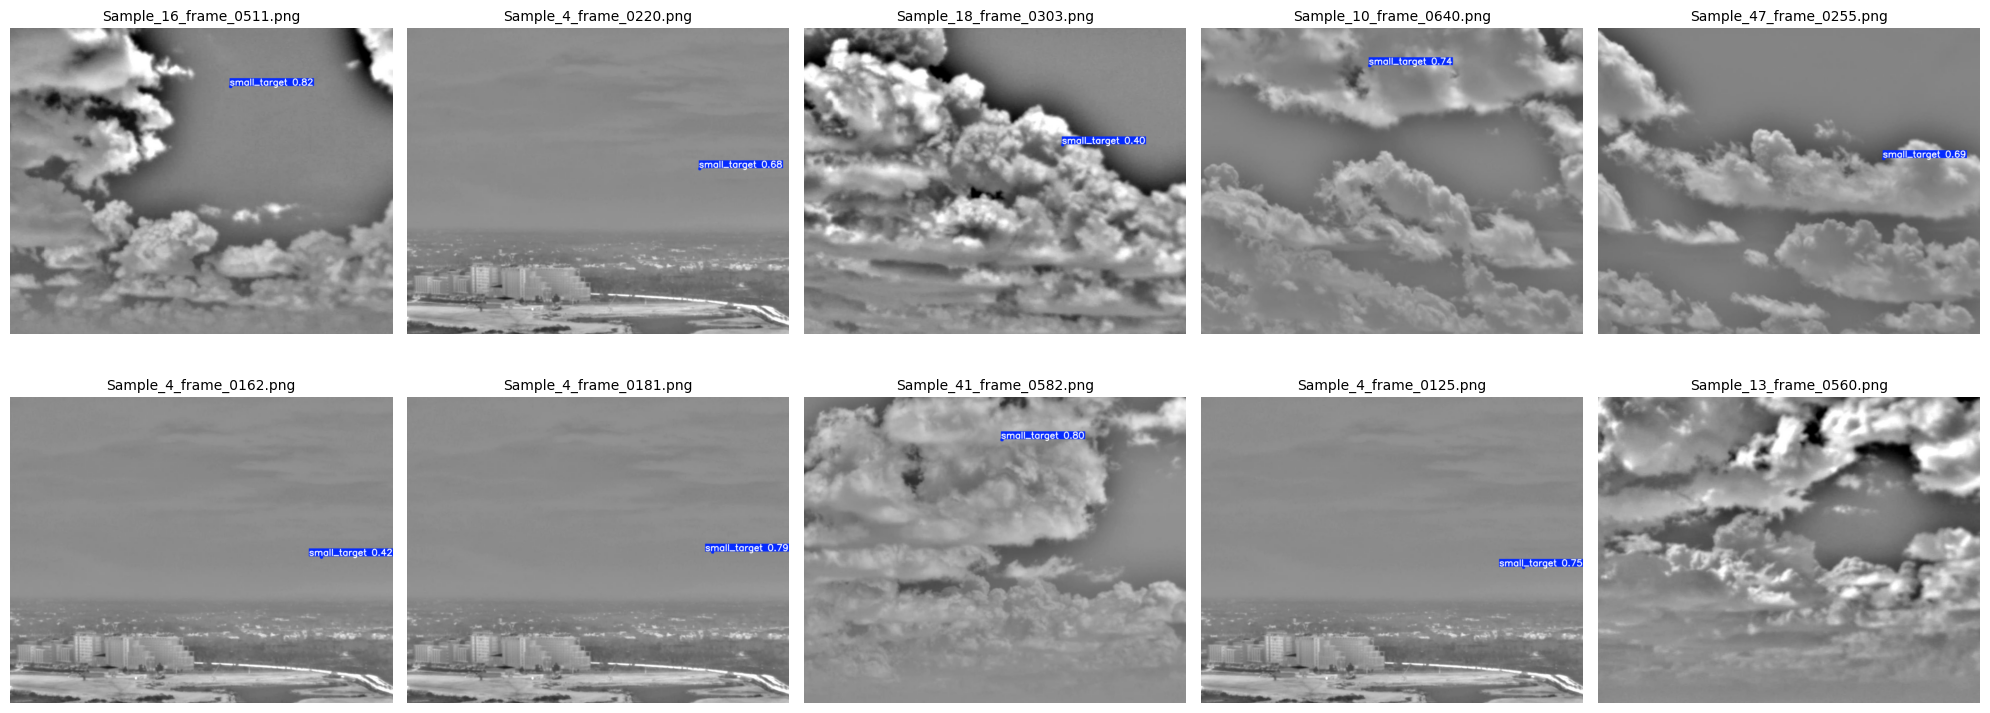

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

weights = glob.glob('/kaggle/working/runs/**/weights/best.pt', recursive=True)
best_model = YOLO(max(weights, key=os.path.getctime))

print("Evaluating metrics on validation set...")
metrics = best_model.val(data='/kaggle/working/data_final.yaml')

p = metrics.box.mp * 100
r = metrics.box.mr * 100
f1 = 2 * (p * r) / (p + r + 1e-16)

print("\n" + "="*45)
print(" NUDT-SIRST METRICS: YOUR MODEL vs TY-RIST PAPER")
print("="*45)
print(f"Metric      | Your YOLO Model   | TY-RIST Paper")
print(f"------------|-------------------|--------------")
print(f"Precision   | {p:.1f}%             | 96.8%")
print(f"Recall      | {r:.1f}%             | 95.8%")
print(f"F1 Score    | {f1:.1f}%             | 96.3%")
print("="*45 + "\n")

print("Plotting 10 sample predictions...")
sample_images = glob.glob('/kaggle/working/yolo26_dataset/images/val/*.png')[:10]
results = best_model.predict(source=sample_images, conf=0.25)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, res in enumerate(results):
    img_rgb = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)

    ax = axes.flatten()[i]
    ax.imshow(img_rgb)
    ax.set_title(os.path.basename(sample_images[i]), fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()